# Deep Learning LSTM and Transformer

input : DS-D dataset train.csv and test.csv

### 1. Import Library

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### 2. Data Loading & Windowing Strategy

In [2]:
# Configuration
PROCESSED_DIR = Path("../data/experiments/DS-C")

def create_sequences(data, seq_length, target_col='RUL_clipped'):
    sequences = []
    targets = []
    
    # Identify feature columns (everything except unit_number and target)
    feature_cols = [c for c in data.columns if c not in ['unit_number', target_col]]
    
    for unit in data['unit_number'].unique():
        unit_data = data[data['unit_number'] == unit]
        
        # We need at least 'seq_length' rows to create one sequence
        if len(unit_data) >= seq_length:
            unit_values = unit_data[feature_cols].values
            target_values = unit_data[target_col].values
            
            for i in range(len(unit_data) - seq_length):
                sequences.append(unit_values[i : i + seq_length])
                targets.append(target_values[i + seq_length])
                
    return np.array(sequences), np.array(targets)

# Load data
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

# Scaling (CRITICAL for Deep Learning)
scaler = StandardScaler()
features = [c for c in train_df.columns if c not in ['unit_number', 'RUL_clipped']]
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

# Generate Sequences
SEQUENCE_LENGTH = 30
X_train, y_train = create_sequences(train_df, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_df, SEQUENCE_LENGTH)

print(f"Train sequences: {X_train.shape}, Labels: {y_train.shape}")

class RULDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]
    
print(f"Total features selected: {len(features)}")
print("--- Selected Feature List ---")
for i, feature in enumerate(features, 1):
    print(f"{i}. {feature}")

print(f"\nShape of X_train: {X_train.shape}")
print(f"Number of features in sequences: {X_train.shape[2]}")

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(RULDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(RULDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

Train sequences: (17631, 30, 33), Labels: (17631,)
Total features selected: 33
--- Selected Feature List ---
1. PC_1
2. PC_2
3. PC_3
4. PC_4
5. PC_5
6. PC_6
7. PC_7
8. PC_8
9. PC_9
10. PC_10
11. PC_11
12. PC_12
13. PC_13
14. PC_14
15. PC_15
16. PC_16
17. PC_17
18. PC_18
19. PC_19
20. PC_20
21. PC_21
22. PC_22
23. PC_23
24. PC_24
25. PC_25
26. PC_26
27. PC_27
28. PC_28
29. PC_29
30. PC_30
31. PC_31
32. PC_32
33. PC_33

Shape of X_train: (17631, 30, 33)
Number of features in sequences: 33


### 3. The LSTM Model Architecture

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) # Take last time step
        return out

input_dim = X_train.shape[2] 
model = LSTMModel(input_dim, hidden_dim=64, num_layers=2, output_dim=1).to(device)

### 5. Training & Evaluation Logic

In [4]:
# --- Early Stopping Class ---
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Initialize
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)
early_stopping = EarlyStopping(patience=3, min_delta=0.05)

epochs = 50

for epoch in range(epochs):
    model.train()
    train_running_sq_error = 0
    total_samples = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X).squeeze()
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        # Accumulate squared error for the whole epoch
        # loss.item() is already the Mean Squared Error of the batch
        train_running_sq_error += loss.item() * batch_X.size(0)
        total_samples += batch_X.size(0)
    
    # Correct calculation: MSE of all samples, then Root
    train_mse = train_running_sq_error / total_samples
    train_rmse = train_mse ** 0.5
    
    # --- Validation / Test Step for Early Stopping ---
    model.eval()
    test_running_sq_error = 0
    test_samples = 0
    with torch.no_grad():
        for b_X, b_y in test_loader:
            b_X, b_y = b_X.to(device), b_y.to(device)
            preds = model(b_X).squeeze()
            test_loss = criterion(preds, b_y)
            test_running_sq_error += test_loss.item() * b_X.size(0)
            test_samples += b_X.size(0)
            
    test_mse = test_running_sq_error / test_samples
    test_rmse = test_mse ** 0.5

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

    # Check Early Stopping
    early_stopping(test_mse)
    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [5/50] | Train RMSE: 45.3464 | Test RMSE: 47.8956
Epoch [10/50] | Train RMSE: 41.7948 | Test RMSE: 38.3374
Epoch [15/50] | Train RMSE: 14.9211 | Test RMSE: 18.4576
Epoch [20/50] | Train RMSE: 3.5818 | Test RMSE: 16.4386
Early stopping triggered at epoch 21


### 6. Run and Visualisation


--- Final Results ---
Final Train RMSE: 2.5492
Final Test RMSE: 16.4142


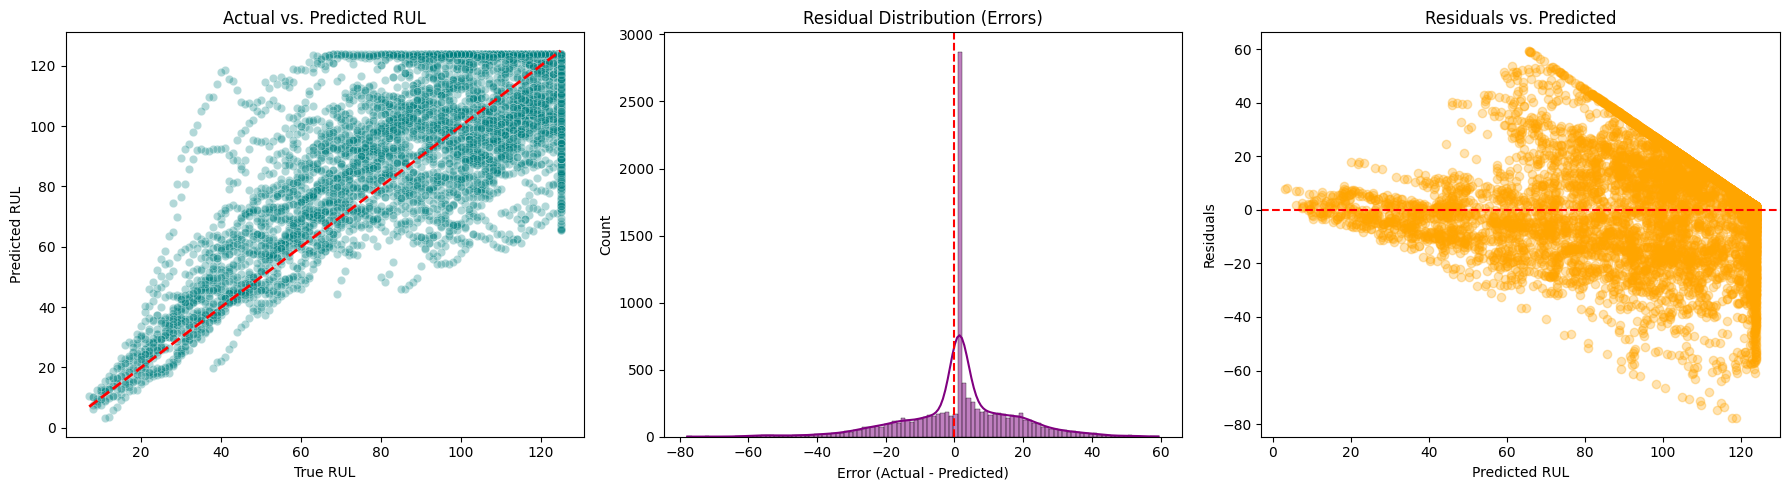

--- Diagnostic Summary ---
Mean Absolute Error (MAE): 11.29
Average Bias: 1.52 (Positive means under-predicting, Negative means over-predicting)


In [5]:
# 1. Run inference to get predictions and actuals
model.eval()
predictions = []
actuals = []

def calculate_final_rmse(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            all_preds.extend(outputs.squeeze().cpu().numpy())
            all_targets.extend(batch_y.numpy())
    
    mse = np.mean((np.array(all_preds) - np.array(all_targets))**2)
    rmse = mse ** 0.5 
    return rmse

# Calculate final values
final_train_rmse = calculate_final_rmse(train_loader, model)
final_test_rmse = calculate_final_rmse(test_loader, model)

# 3. Add: Print final results
print(f"\n--- Final Results ---")
print(f"Final Train RMSE: {final_train_rmse:.4f}")
print(f"Final Test RMSE: {final_test_rmse:.4f}")

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        predictions.extend(outputs.squeeze().cpu().numpy())
        actuals.extend(batch_y.numpy())

# Convert to numpy arrays for calculation
actuals = np.array(actuals)
predictions = np.array(predictions)
residuals = actuals - predictions

# 2. Generate Prediction Diagnostics
plt.figure(figsize=(18, 5))

# Plot A: Actual vs. Predicted
# Ideally points should follow the diagonal red line
plt.subplot(1, 3, 1)
sns.scatterplot(x=actuals, y=predictions, alpha=0.3, color='teal')
plt.plot([actuals.min(), actuals.max()], [actuals.min(), actuals.max()], '--r', lw=2)
plt.title('Actual vs. Predicted RUL')
plt.xlabel('True RUL')
plt.ylabel('Predicted RUL')

# Plot B: Residual Distribution
# Checks if errors are normally distributed (centered at 0)
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Residual Distribution (Errors)')
plt.xlabel('Error (Actual - Predicted)')

# Plot C: Residuals vs. Predicted
# Checks for heteroscedasticity (if error grows with RUL)
plt.subplot(1, 3, 3)
plt.scatter(predictions, residuals, alpha=0.3, color='orange')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted')
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

# 3. Print Summary Diagnostic Metrics
mae = np.mean(np.abs(residuals))
bias = np.mean(residuals)
print(f"--- Diagnostic Summary ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Average Bias: {bias:.2f} (Positive means under-predicting, Negative means over-predicting)")

In [6]:
import torch
import os

# Create the directory
os.makedirs('artifacts', exist_ok=True)

# Define the path
LSTM_PATH = "artifacts/lstm_model.pth"

# Save the state_dict
torch.save({
    'model_state_dict': model.state_dict(),
    'input_dim': input_dim,
    'hidden_dim': 64,
    'num_layers': 2,
    'output_dim': 1
}, LSTM_PATH)

print(f"LSTM Model saved to {LSTM_PATH}")

LSTM Model saved to artifacts/lstm_model.pth
